# 35 — Individual-to-polity matching recovery

How each individual is assigned to a Cliopatria polity, and **where the match comes from**.

Two complementary techniques are tried in a strict cascade by `04_individuals_cliopatria_rs`. Each individual is counted **once**, on the first matching source — so the per-row counts already form a recursive coverage table (sum to the total matched).

Order of recovery (matching the matcher's cascade):

1. **Polygon · deathplace** — death city's `(lon,lat)` falls inside a polity-period polygon active in the impact year (smallest bbox wins on ties).
2. **Polygon · birthplace** — same logic, falling back to the birth city.
3. **Polygon · country_of_citizenship** — same logic, using the country-of-citizenship centroid (smallest bbox across all listed countries).
4. **URL · country_of_citizenship** — country-of-citizenship Wikipedia URL joined to `polities_cliopatria.wikipedia_url`, restricted to year-active periods.
5. **URL · deathplace** — same URL logic, falling back to the death city.
6. **URL · birthplace** — same URL logic, falling back to the birth city.

Impact year = midpoint of `(floruit_period_start, floruit_period_end)` when both are present, else `floruit_year`. Individuals with no impact year are skipped.

We then report the share of each method against three meaningful denominators: all individuals, all dated individuals (the matcher's input pool), and all individuals that have both a date AND at least one location identifier (the "could-possibly-match" pool).

In [1]:
# === notebook config (auto-managed; edit values, not the tag) ===
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DB_PATH = "../data/humans_clean.duckdb"

# Figure style — minimal, Nature/Science publication standard
FIGSIZE = (8, 5)
DPI = 120
FONT_TITLE = 16
FONT_LABEL = 13
FONT_TICK = 11
FONT_LEGEND = 10

# Two-tone palette: polygon vs URL, with light shading by location origin.
COLOR_POLY_DEATH = "#1f4f7a"
COLOR_POLY_BIRTH = "#3a8fbf"
COLOR_POLY_COC   = "#7fb8d6"
COLOR_URL_COC    = "#b5542a"
COLOR_URL_DEATH  = "#d97a4f"
COLOR_URL_BIRTH  = "#e8a37a"
COLOR_NONE       = "#d9d9d9"

import matplotlib as _mpl
_mpl.rcParams.update({
    "figure.figsize": FIGSIZE,
    "figure.dpi": DPI,
    "axes.titlesize": FONT_TITLE,
    "axes.labelsize": FONT_LABEL,
    "xtick.labelsize": FONT_TICK,
    "ytick.labelsize": FONT_TICK,
    "legend.fontsize": FONT_LEGEND,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})

## 1. Load

In [2]:
import duckdb
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

conn = duckdb.connect(DB_PATH, read_only=True)

# Per-individual cascade outcome (one row per matched individual).
matches_pd = conn.execute("""
    SELECT wikidata_id, method, origin
    FROM individuals_cliopatria
""").df()

# Denominators.
n_total = conn.execute("SELECT COUNT(*) FROM individuals").fetchone()[0]

n_with_year = conn.execute("""
    SELECT COUNT(DISTINCT i.wikidata_id)
    FROM individuals i
    LEFT JOIN individuals_floruit_period f ON i.wikidata_id = f.wikidata_id
    WHERE f.floruit_year IS NOT NULL
       OR (f.floruit_period_start IS NOT NULL AND f.floruit_period_end IS NOT NULL)
""").fetchone()[0]

n_with_year_and_loc = conn.execute("""
    SELECT COUNT(DISTINCT i.wikidata_id)
    FROM individuals i
    LEFT JOIN individuals_floruit_period f ON i.wikidata_id = f.wikidata_id
    LEFT JOIN individuals_keys k ON i.wikidata_id = k.wikidata_id
    WHERE (f.floruit_year IS NOT NULL
           OR (f.floruit_period_start IS NOT NULL AND f.floruit_period_end IS NOT NULL))
      AND (NULLIF(k.birthcity_id,'') IS NOT NULL
           OR NULLIF(k.deathcity_id,'') IS NOT NULL
           OR NULLIF(k.country_of_citizenship_ids,'') IS NOT NULL)
""").fetchone()[0]
conn.close()

matches = pl.from_pandas(matches_pd)
del matches_pd

print(f"individuals (total)                                 : {n_total:,}")
print(f"individuals with a usable year (matcher input pool) : {n_with_year:,}")
print(f"individuals with year AND at least one location key : {n_with_year_and_loc:,}")
print(f"matched (in individuals_cliopatria)                 : {matches.height:,}")
matches.head()

/Users/charlesdedampierre/Desktop/Rsearch Folder/cultura_database/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


individuals (total)                                 : 13,003,420
individuals with a usable year (matcher input pool) : 9,683,814
individuals with year AND at least one location key : 5,199,978
matched (in individuals_cliopatria)                 : 5,065,026


wikidata_id,method,origin
str,str,str
"""Q107522""","""merge_with_polygon""","""deathplace"""
"""Q107522041""","""merge_with_polygon""","""deathplace"""
"""Q107522056""","""merge_with_polygon""","""birthplace"""
"""Q107522108""","""merge_with_polygon""","""birthplace"""
"""Q107522122""","""merge_with_polygon""","""birthplace"""


## 2. Breakdown by (method, origin)

Because the matcher's cascade assigns each individual to exactly one (method, origin) bucket, the per-row counts are already mutually exclusive — they sum to the total matched.

In [3]:
# Cascade order — the priority order the matcher uses internally.
CASCADE = [
    ("polygon", "deathplace"),
    ("polygon", "birthplace"),
    ("polygon", "country_of_citizenship"),
    ("url",     "country_of_citizenship"),
    ("url",     "deathplace"),
    ("url",     "birthplace"),
]

# The matcher stores method as 'merge_with_polygon' / 'merge_with_url'.
norm = (matches
    .with_columns(
        pl.when(pl.col("method") == "merge_with_polygon").then(pl.lit("polygon"))
          .when(pl.col("method") == "merge_with_url").then(pl.lit("url"))
          .otherwise(pl.col("method"))
          .alias("method_short"),
    )
)

raw_counts = (
    norm.group_by(["method_short", "origin"])
        .agg(pl.len().alias("count"))
        .rename({"method_short": "method"})
)

# Order rows by the cascade.
ord_df = pl.DataFrame({
    "method":   [m for m, _ in CASCADE],
    "origin":   [o for _, o in CASCADE],
    "_order":   list(range(len(CASCADE))),
})
breakdown = (
    ord_df.join(raw_counts, on=["method", "origin"], how="left")
          .with_columns(pl.col("count").fill_null(0))
          .sort("_order")
          .drop("_order")
)

n_matched_total = int(breakdown["count"].sum())
assert n_matched_total == matches.height, "cascade buckets must sum to total matched"

print(f"Total matched: {n_matched_total:,}")
breakdown

Total matched: 5,065,026


method,origin,count
str,str,u32
"""polygon""","""deathplace""",1452327
"""polygon""","""birthplace""",1982607
"""polygon""","""country_of_citizenship""",1547029
"""url""","""country_of_citizenship""",73146
"""url""","""deathplace""",1848
"""url""","""birthplace""",8069


## 3. Recursive coverage table (Table 5 style)

Each row reports the share of individuals **newly matched** by that source and the **cumulative coverage** after applying it. We report two cumulative shares:

- against **all dated individuals** (the matcher's eligible input pool — needs an impact year),
- against **all individuals** (for context).

The first denominator is the right one for the paper paragraph (you can only assign a polity to someone you can date).

In [4]:
label_map = {
    ("polygon", "deathplace"):              "From deathplace polygon",
    ("polygon", "birthplace"):              "From birthplace polygon",
    ("polygon", "country_of_citizenship"):  "From country-of-citizenship polygon",
    ("url",     "country_of_citizenship"):  "From country-of-citizenship Wikipedia URL",
    ("url",     "deathplace"):              "From deathplace Wikipedia URL",
    ("url",     "birthplace"):              "From birthplace Wikipedia URL",
}

rows_pd = breakdown.to_pandas()
rows_pd["label"] = rows_pd.apply(lambda r: label_map[(r["method"], r["origin"])], axis=1)
rows_pd["share_dated_%"] = (rows_pd["count"] / n_with_year * 100).round(2)
rows_pd["share_total_%"] = (rows_pd["count"] / n_total      * 100).round(2)
rows_pd["cum_dated_%"]   = rows_pd["share_dated_%"].cumsum().round(2)
rows_pd["cum_total_%"]   = rows_pd["share_total_%"].cumsum().round(2)

table5 = rows_pd[["label", "method", "origin", "count",
                  "share_dated_%", "cum_dated_%",
                  "share_total_%", "cum_total_%"]]
table5

,label,method,origin,count,share_dated_%,cum_dated_%,share_total_%,cum_total_%
0,From deathplace polygon,polygon,deathplace,1452327,15.00,15.00,11.17,11.17
1,From birthplace polygon,polygon,birthplace,1982607,20.47,35.47,15.25,26.42
2,From country-of-citizenship polygon,polygon,country_of_citizenship,1547029,15.98,51.45,11.90,38.32
3,From country-of-citizenship Wikipedia URL,url,country_of_citizenship,73146,0.76,52.21,0.56,38.88
4,From deathplace Wikipedia URL,url,deathplace,1848,0.02,52.23,0.01,38.89
5,From birthplace Wikipedia URL,url,birthplace,8069,0.08,52.31,0.06,38.95


In [5]:
share_dated_total = n_matched_total / n_with_year * 100
share_total_total = n_matched_total / n_total      * 100
share_eligible    = n_matched_total / n_with_year_and_loc * 100

print(f"Total matched:                                            {n_matched_total:,}")
print(f"  share of dated individuals (n={n_with_year:,})       : {share_dated_total:.2f}%")
print(f"  share of all individuals  (n={n_total:,})            : {share_total_total:.2f}%")
print(f"  share of dated AND located individuals (n={n_with_year_and_loc:,}): {share_eligible:.2f}%")

Total matched:                                            5,065,026
  share of dated individuals (n=9,683,814)       : 52.30%
  share of all individuals  (n=13,003,420)            : 38.95%
  share of dated AND located individuals (n=5,199,978): 97.40%


## 4. Markdown rendering — Table 5

Drop-in markdown for the paper, formatted like Table 4.

In [6]:
def fmt_share(p):
    return "<0.01%" if 0 < p < 0.01 else f"{p:.2f}%"

lines = [
    "| Method | Unique individuals matched | Cumulative coverage |",
    "|---|---:|---:|",
]
for _, r in rows_pd.iterrows():
    add = fmt_share(r["share_dated_%"])
    cum = fmt_share(r["cum_dated_%"])
    lines.append(f"| {r['label']} | +{add} | {cum} |")

lines.append(f"| **Total matched to a polity** | **{share_dated_total:.2f}%** | **{share_dated_total:.2f}%** |")

md = "\n".join(lines)
print(md)

| Method | Unique individuals matched | Cumulative coverage |
|---|---:|---:|
| From deathplace polygon | +15.00% | 15.00% |
| From birthplace polygon | +20.47% | 35.47% |
| From country-of-citizenship polygon | +15.98% | 51.45% |
| From country-of-citizenship Wikipedia URL | +0.76% | 52.21% |
| From deathplace Wikipedia URL | +0.02% | 52.23% |
| From birthplace Wikipedia URL | +0.08% | 52.31% |
| **Total matched to a polity** | **52.30%** | **52.30%** |


In [7]:
# Raw count rendering (mirrors the user's reference table exactly).
lines = [
    "| method | origin | count |",
    "|---|---|---:|",
]
for _, r in rows_pd.iterrows():
    lines.append(f"| {r['method']} | {r['origin']} | {int(r['count']):,} |")
lines.append(f"| **total** |  | **{n_matched_total:,}** |")
print("\n".join(lines))

| method | origin | count |
|---|---|---:|
| polygon | deathplace | 1,452,327 |
| polygon | birthplace | 1,982,607 |
| polygon | country_of_citizenship | 1,547,029 |
| url | country_of_citizenship | 73,146 |
| url | deathplace | 1,848 |
| url | birthplace | 8,069 |
| **total** |  | **5,065,026** |


## 5. Figure — recovery breakdown

Horizontal bars showing each method's contribution, in cascade order. Polygon-based methods (cool tones) dominate; URL fallbacks (warm tones) close residual gaps.

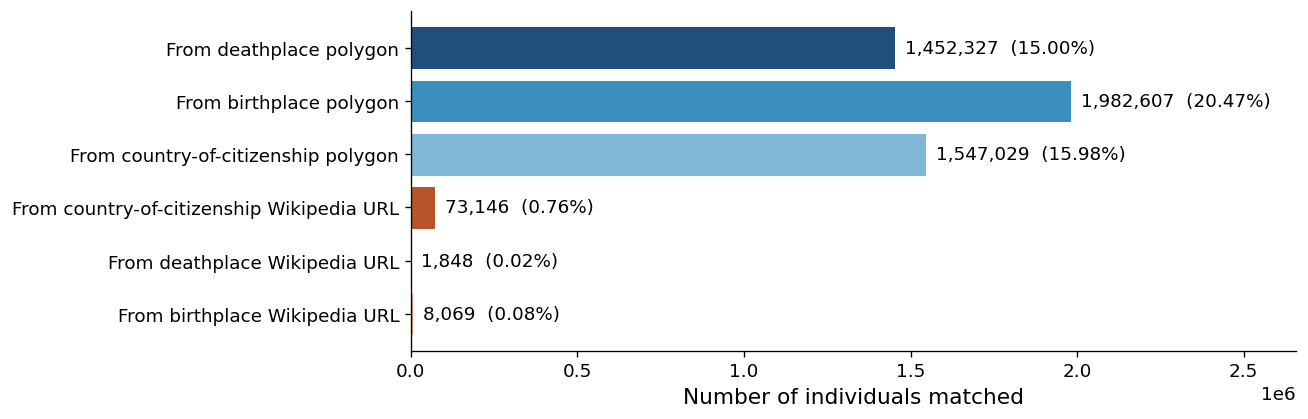

In [8]:
color_map = {
    ("polygon", "deathplace"):              COLOR_POLY_DEATH,
    ("polygon", "birthplace"):              COLOR_POLY_BIRTH,
    ("polygon", "country_of_citizenship"):  COLOR_POLY_COC,
    ("url",     "country_of_citizenship"):  COLOR_URL_COC,
    ("url",     "deathplace"):              COLOR_URL_DEATH,
    ("url",     "birthplace"):              COLOR_URL_BIRTH,
}

plot_df = rows_pd.copy()
plot_df["color"] = plot_df.apply(lambda r: color_map[(r["method"], r["origin"])], axis=1)

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.barh(plot_df["label"], plot_df["count"],
        color=plot_df["color"], edgecolor="white", linewidth=0.6)
for y, (n, p) in enumerate(zip(plot_df["count"], plot_df["share_dated_%"])):
    ax.annotate(f"{int(n):,}  ({p:.2f}%)", xy=(n, y),
                xytext=(6, 0), textcoords="offset points",
                va="center", fontsize=11)
ax.set_xlabel("Number of individuals matched")
ax.invert_yaxis()
ax.margins(x=0.34)
plt.tight_layout()
plt.show()

## 6. Paragraph rendering

In [9]:
n = {(r['method'], r['origin']): int(r['count']) for _, r in rows_pd.iterrows()}
n_poly = sum(v for k, v in n.items() if k[0] == "polygon")
n_url  = sum(v for k, v in n.items() if k[0] == "url")

print(f"""Each individual is assigned to a Cliopatria polity through a strict cascade.
First, polygon matching is tried in deathplace -> birthplace -> country-of-citizenship
order: the place's coordinates must fall inside a polity-period polygon active in the
individual's impact year (smallest bbox wins on ties). Polygon matching alone resolves
{n_poly:,} individuals
(deathplace: {n[("polygon", "deathplace")]:,};
 birthplace: {n[("polygon", "birthplace")]:,};
 country-of-citizenship: {n[("polygon", "country_of_citizenship")]:,}).
Wikipedia URL matching, applied in country-of-citizenship -> deathplace -> birthplace
order to individuals still unmatched, recovers {n_url:,} additional individuals
(country-of-citizenship URL: {n[("url", "country_of_citizenship")]:,};
 deathplace URL: {n[("url", "deathplace")]:,};
 birthplace URL: {n[("url", "birthplace")]:,}).
In total {n_matched_total:,} individuals are matched to a Cliopatria polity
({share_dated_total:.1f}% of the {n_with_year:,} dated individuals,
 {share_eligible:.1f}% of the {n_with_year_and_loc:,} dated individuals
 who carry at least one location identifier).""")

Each individual is assigned to a Cliopatria polity through a strict cascade.
First, polygon matching is tried in deathplace -> birthplace -> country-of-citizenship
order: the place's coordinates must fall inside a polity-period polygon active in the
individual's impact year (smallest bbox wins on ties). Polygon matching alone resolves
4,981,963 individuals
(deathplace: 1,452,327;
 birthplace: 1,982,607;
 country-of-citizenship: 1,547,029).
Wikipedia URL matching, applied in country-of-citizenship -> deathplace -> birthplace
order to individuals still unmatched, recovers 83,063 additional individuals
(country-of-citizenship URL: 73,146;
 deathplace URL: 1,848;
 birthplace URL: 8,069).
In total 5,065,026 individuals are matched to a Cliopatria polity
(52.3% of the 9,683,814 dated individuals,
 97.4% of the 5,199,978 dated individuals
 who carry at least one location identifier).
